In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator
import cv2

In [ ]:
name = 'Mahmoud'

In [ ]:
cap = cv2.VideoCapture(0) #Test Project.avi 
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)

count = 0
output = "data_Recognition_Yolo/{name}"
os.makedirs(output,exist_ok=True)

# Initialize YOLO model
model = YOLO('YoloV8 Face.pt')
names = model.model.names

skip = 0
while cap.isOpened() :

    ret, frame = cap.read()
    if not ret:
        break
    frame_BGR=frame.copy()
    r, c, _ = frame.shape
    annotator = Annotator(frame, line_width=2)
    if skip % 15 == 0 :
        # Run YOLO inference
        results = model.track(frame, iou=0.3, show=False, tracker="bytetrack.yaml", persist=True, verbose=False)

        if results[0].boxes.id is not None:
            track_ids = results[0].boxes.id.int().cpu().tolist()
            clss = "Face" #names[results[0].boxes.cls.int().cpu().tolist()[0]]
            boxes = results[0].boxes.xyxy.cpu()
            conf = results[0].boxes.conf.tolist()

            for box, track_id, cof, cc in zip(boxes, track_ids, conf, clss):
                x1, y1, x2, y2 = box.int().tolist()
                
                face = frame_BGR[y1:y2, x1:x2]
                cv2.imwrite(f'{output}/img{count}.jpg', face)
                count = count + 1
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 3)
                    
            frame=cv2.cvtColor(frame,cv2.COLOR_RGB2BGR)
    skip += 1
    cv2.imshow("Project", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'): # if press q
        break

cap.release()
cv2.destroyAllWindows()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import glob as gb
from tqdm import tqdm

In [4]:
trainpath = 'data_Recognition_Yolo/'
new_size=96    
X_train = []
y_train = []
for folder in  os.listdir(trainpath) : 
    print( 'folder name is : ', folder)
    files = gb.glob(pathname= str( trainpath  + folder + '/*.jpg'))
    print( 'numbers of images in folder are : ', len(files))
    print(' start reading images')
    for file in files: 
        orignal_image = cv2.imread(file)
        image = cv2.cvtColor(orignal_image, cv2.COLOR_BGR2RGB)
        resized_image = cv2.resize(image , (new_size,new_size))
        X_train.append(resized_image)
        y_train.append(folder)
    print('image reading ...finished')
print('--------------------------------------------------')        
#check items in X_test
print("items in X_train is:       ",len(X_train) , " items") 
print("items in y_train is:       ",len(y_train) , " items") 

folder name is :  Mahmoud
numbers of images in folder are :  13
 start reading images
image reading ...finished
--------------------------------------------------
items in X_train is:        13  items
items in y_train is:        13  items


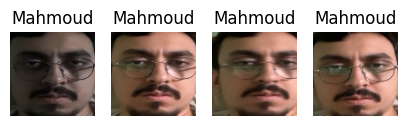

In [5]:
#showing training images with labels
plt.figure(figsize=(5,5))
for n , i in enumerate(list(np.random.randint(0,len(X_train ),4))) : 
    plt.subplot(1,4,n+1)
    plt.imshow(X_train[i])   

    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [6]:
X_train=np.array(X_train)
y_train=np.array(y_train)

In [7]:
X_train = X_train / 255.0

In [8]:
#shuffle data
from sklearn.utils import shuffle
X_train,y_train = shuffle(X_train,y_train)

In [9]:
from Openface import load_model
model = load_model()
#model.summary()

In [10]:
embeddings = model.predict(X_train,verbose=0)

In [11]:
embeddings

array([[  -0.048471,     0.02834,    0.050155, ...,    0.034017,     0.14246,     0.13704],
       [  -0.055977,    0.089397,   0.0079942, ...,    0.056838,     0.10893,    0.066734],
       [  -0.098251,    0.043702,   0.0076005, ...,    0.066329,    0.065959,     0.13802],
       ...,
       [  -0.099845,    0.018572,  -0.0029558, ...,    0.071986,    0.093756,     0.10746],
       [  -0.074777,    0.068361,  -0.0037873, ...,    0.039354,     0.18514,     0.10921],
       [   -0.10256,    0.050292,     0.02468, ...,     0.07638,     0.11298,     0.11756]], dtype=float32)

In [12]:
y_train

array(['Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud', 'Mahmoud'], dtype='<U7')

In [13]:
# Reshape y_train to have one column
y_train_reshaped = y_train.reshape(-1, 1)

In [14]:
y_train_reshaped

array([['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud'],
       ['Mahmoud']], dtype='<U7')

In [15]:
# Now concatenate embeddings and y_train_reshaped along axis 1 (columns)
w = np.concatenate((embeddings, y_train_reshaped), axis=1)

In [16]:
data=pd.DataFrame(w)

In [17]:
data.to_csv('Face Recognition.csv',index=None)

In [18]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,128
0,-0.048471436,0.028339826,0.05015522,-0.019376075,-0.03836474,0.18461081,-0.040478934,0.033730093,0.04145579,-0.028995192,...,0.07834142,0.08551607,-0.13091645,-0.04133549,-0.013658653,-0.011271247,0.03401664,0.14246476,0.13703953,Mahmoud
1,-0.055977423,0.089397214,0.007994153,0.074695915,0.012792804,0.22234301,-0.021984344,-0.10224587,0.04787028,-0.0058891564,...,0.13463342,0.12781066,-0.09211317,-0.06200571,-0.03416801,0.006631063,0.056837577,0.10892875,0.066733845,Mahmoud
2,-0.09825132,0.043701913,0.007600532,-0.018426618,-0.021928614,0.17992131,-0.023861004,0.007523217,0.1045368,0.037169263,...,0.11761048,0.11317449,-0.11849806,-0.098103456,0.012451068,-0.05345081,0.06632859,0.06595945,0.13802433,Mahmoud
3,-0.099999204,0.1004472,-0.016705967,0.02384158,0.004840317,0.20450094,-0.033224575,-0.10611318,0.096274205,0.03206601,...,0.112543575,0.15178622,-0.10052577,-0.044570446,-0.025414307,-0.053423095,0.07977508,0.074222356,0.0735849,Mahmoud
4,-0.055939153,0.023852065,0.032696348,0.018462943,-0.04423868,0.18539806,-0.035124887,-0.024611901,0.0881276,-0.00856872,...,0.09062735,0.13186166,-0.13252884,-0.031593837,0.0022360408,0.015873471,0.039938975,0.16717628,0.1396087,Mahmoud
